****Response Weight Sensitivity Analysis****

In [41]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd

pd.set_option("display.max_columns", None)

In [42]:
def find_project_root():
    current = Path.cwd().resolve()

    for candidate in [current] + list(current.parents):
        if (
            (candidate / "src").exists()
            and (candidate / "optimization").exists()
            and (candidate / "experiment_results").exists()
        ):
            return candidate

    raise FileNotFoundError(
        "Project root was not found."
    )

In [43]:
PROJECT_ROOT = find_project_root()

RESULT_DIR = (PROJECT_ROOT/ "experiment_results"/ "response_weight_sensitivity"/ "nelder_mead")
FIGURE_DIR = (PROJECT_ROOT/ "Figs"/ "response_weight_sensitivity")

FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("RESULT_DIR:", RESULT_DIR)
print("FIGURE_DIR:", FIGURE_DIR)

PROJECT_ROOT: C:\Users\caoxb\PycharmProjects\ATM_simulation
RESULT_DIR: C:\Users\caoxb\PycharmProjects\ATM_simulation\experiment_results\response_weight_sensitivity\nelder_mead
FIGURE_DIR: C:\Users\caoxb\PycharmProjects\ATM_simulation\Figs\response_weight_sensitivity


Load Experimental Results

In [44]:
SENSITIVITY_N_VALUES = [50, 75, 100]
SENSITIVITY_WEIGHTS = [100, 1000, 10000, 50000]

records = []

for n in SENSITIVITY_N_VALUES:
    for weight in SENSITIVITY_WEIGHTS:
        result_folder = RESULT_DIR / f"n{n}" / f"w{weight}"
        matched_files = sorted(result_folder.glob("*best_result*.csv"))

        if len(matched_files) != 1:
            raise FileNotFoundError(
                f"Expected exactly one best_result CSV for n={n}, weight={weight}, "
                f"but found {len(matched_files)} in {result_folder}"
            )

        df = pd.read_csv(matched_files[0])

        required_columns = [
            "selected_objective",
            "average_response_time",
        ]

        missing_columns = [
            col for col in required_columns if col not in df.columns
        ]

        if missing_columns:
            raise KeyError(
                f"Missing columns in {matched_files[0]}: {missing_columns}"
            )

        mean_objective = df["selected_objective"].mean()
        mean_response_time = df["average_response_time"].mean()

        response_penalty = weight * mean_response_time
        response_penalty_percentage = response_penalty / mean_objective * 100

        records.append(
            {
                "num_servers": n,
                "response_time_weight": weight,
                "response_penalty_percentage": response_penalty_percentage,
            }
        )

plot_df = (
    pd.DataFrame(records)
    .sort_values(["num_servers", "response_time_weight"])
    .reset_index(drop=True)
)

Plot Figure

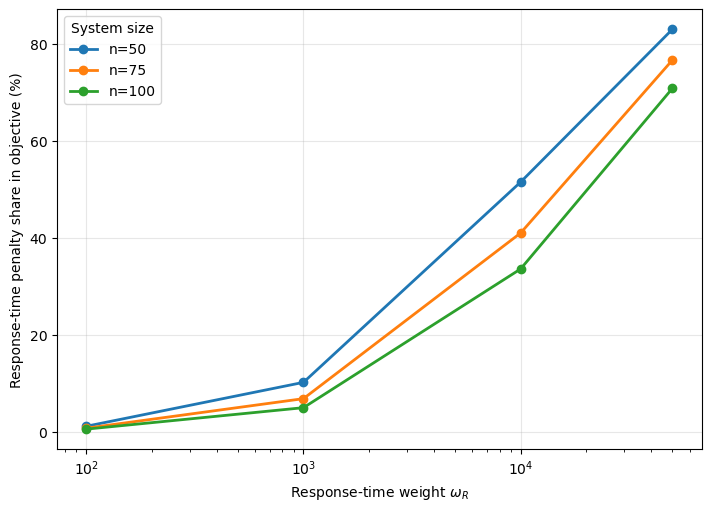

In [45]:
fig, ax = plt.subplots(figsize=(7, 5), constrained_layout=True)

for n, group in plot_df.groupby("num_servers"):
    group = group.sort_values("response_time_weight")

    ax.plot(
        group["response_time_weight"],
        group["response_penalty_percentage"],
        marker="o",
        linewidth=2,
        label=f"n={n}",
    )

ax.set_xscale("log")

ax.set_xlabel(r"Response-time weight $\omega_R$")
ax.set_ylabel("Response-time penalty share in objective (%)")
# ax.set_title("Response-time penalty share under different weights")

ax.grid(alpha=0.3)
ax.legend(title="System size")

plt.savefig(
    FIGURE_DIR / "response_penalty_share_by_weight.png",
    dpi=300,
)

plt.show()